# Model Analysis: Accuracy, Correlation Matrix, Confusion Matrix & Diagnostic Plots

This notebook provides comprehensive analysis of the trained models on the STARC-9 dataset, including:
- **Accuracy Metrics**: Overall accuracy, precision, recall, F1-scores
- **Correlation Matrix**: Per-class metric correlations
- **Confusion Matrix**: Visual representation with annotations
- **Performance Visualizations**: ROC curves, precision-recall curves, per-class metrics
- **Diagnostic Analysis**: Class-wise performance breakdown

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Define paths
EVAL_DIR = r"C:\Users\Sai Koushik\Desktop\FP_REF\STARC-9-Evaluation\save_results"
CUSTOM_CNN_DIR = f"{EVAL_DIR}\custom_cnn"
RESNET50_DIR = f"{EVAL_DIR}\resnet50"

# Load Custom CNN evaluation data
with open(f"{CUSTOM_CNN_DIR}\custom_cnn_evaluation.json", 'r') as f:
    custom_cnn_eval = json.load(f)

# Load ResNet50 evaluation data (if available)
try:
    with open(f"{RESNET50_DIR}\resnet50_evaluation.json", 'r') as f:
        resnet50_eval = json.load(f)
    models_available = ['custom_cnn', 'resnet50']
except:
    resnet50_eval = None
    models_available = ['custom_cnn']
    print("⚠ ResNet50 evaluation data not found")

# Load per-class metrics CSV
custom_cnn_metrics_df = pd.read_csv(f"{CUSTOM_CNN_DIR}\custom_cnn_per_class_metrics.csv")

print(f"✓ Data loaded successfully")
print(f"✓ Models available: {models_available}")
print(f"\nDataset classes: {custom_cnn_metrics_df['class'].tolist()}")

⚠ ResNet50 evaluation data not found
✓ Data loaded successfully
✓ Models available: ['custom_cnn']

Dataset classes: ['ADI', 'LYM', 'MUC', 'MUS', 'NCS', 'NOR', 'BLD', 'FCT', 'TUM', 'UNCERTAIN']


## 1. Overall Accuracy Metrics

CUSTOM CNN MODEL - OVERALL METRICS
Overall Accuracy:        0.5994 (59.94%)
Macro Precision:         0.6566
Macro Recall:            0.5395
Macro F1-Score:          0.5048
Micro F1-Score (=Acc):   0.5994

Summary Comparison Table:
           Metric  Custom CNN
         Accuracy    0.599444
Precision (Macro)    0.656572
   Recall (Macro)    0.539500
 F1-Score (Macro)    0.504763
 F1-Score (Micro)    0.599444


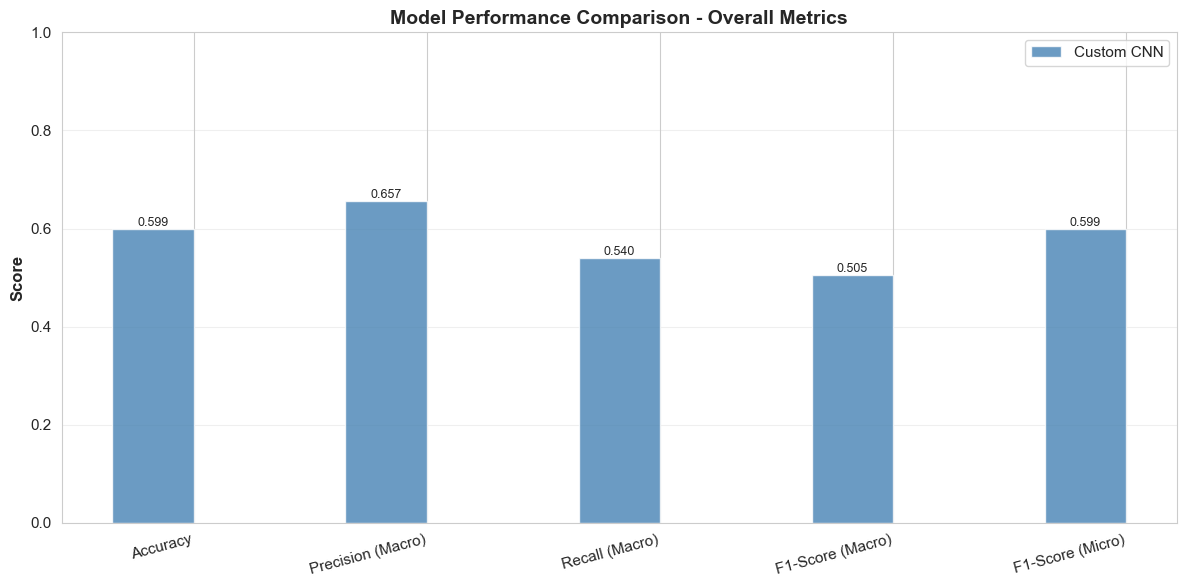


✓ Plot saved to: C:\Users\Sai Koushik\Desktop\FP_REF\STARC-9-Evaluation\save_results\custom_cnn\overall_metrics_comparison.png


In [3]:
# Display Custom CNN Metrics
print("="*70)
print("CUSTOM CNN MODEL - OVERALL METRICS")
print("="*70)
print(f"Overall Accuracy:        {custom_cnn_eval['accuracy']:.4f} ({custom_cnn_eval['accuracy']*100:.2f}%)")
print(f"Macro Precision:         {custom_cnn_eval['precision_macro']:.4f}")
print(f"Macro Recall:            {custom_cnn_eval['recall_macro']:.4f}")
print(f"Macro F1-Score:          {custom_cnn_eval['f1_macro']:.4f}")
print(f"Micro F1-Score (=Acc):   {custom_cnn_eval['f1_micro']:.4f}")
print("="*70)

# Create summary dataframe
summary_data = {
    'Metric': ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)', 'F1-Score (Micro)'],
    'Custom CNN': [
        custom_cnn_eval['accuracy'],
        custom_cnn_eval['precision_macro'],
        custom_cnn_eval['recall_macro'],
        custom_cnn_eval['f1_macro'],
        custom_cnn_eval['f1_micro']
    ]
}

if resnet50_eval:
    summary_data['ResNet50'] = [
        resnet50_eval['accuracy'],
        resnet50_eval['precision_macro'],
        resnet50_eval['recall_macro'],
        resnet50_eval['f1_macro'],
        resnet50_eval['f1_micro']
    ]

summary_df = pd.DataFrame(summary_data)

print("\nSummary Comparison Table:")
print(summary_df.to_string(index=False))

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(summary_df))
width = 0.35

ax.bar(x - width/2, summary_df['Custom CNN'], width, label='Custom CNN', alpha=0.8, color='steelblue')
if 'ResNet50' in summary_df.columns:
    ax.bar(x + width/2, summary_df['ResNet50'], width, label='ResNet50', alpha=0.8, color='coral')

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison - Overall Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(summary_df['Metric'], rotation=15, ha='right')
ax.legend(fontsize=11)
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.3f', fontsize=9)

plt.tight_layout()
plt.savefig(f"{CUSTOM_CNN_DIR}\overall_metrics_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Plot saved to:", f"{CUSTOM_CNN_DIR}\overall_metrics_comparison.png")

## 2. Correlation Matrix - Per-Class Metrics

CORRELATION MATRIX - Per-Class Metrics
           precision  recall  f1_score  accuracy
precision     1.0000  0.1968    0.5918    0.1968
recall        0.1968  1.0000    0.8661    1.0000
f1_score      0.5918  0.8661    1.0000    0.8661
accuracy      0.1968  1.0000    0.8661    1.0000


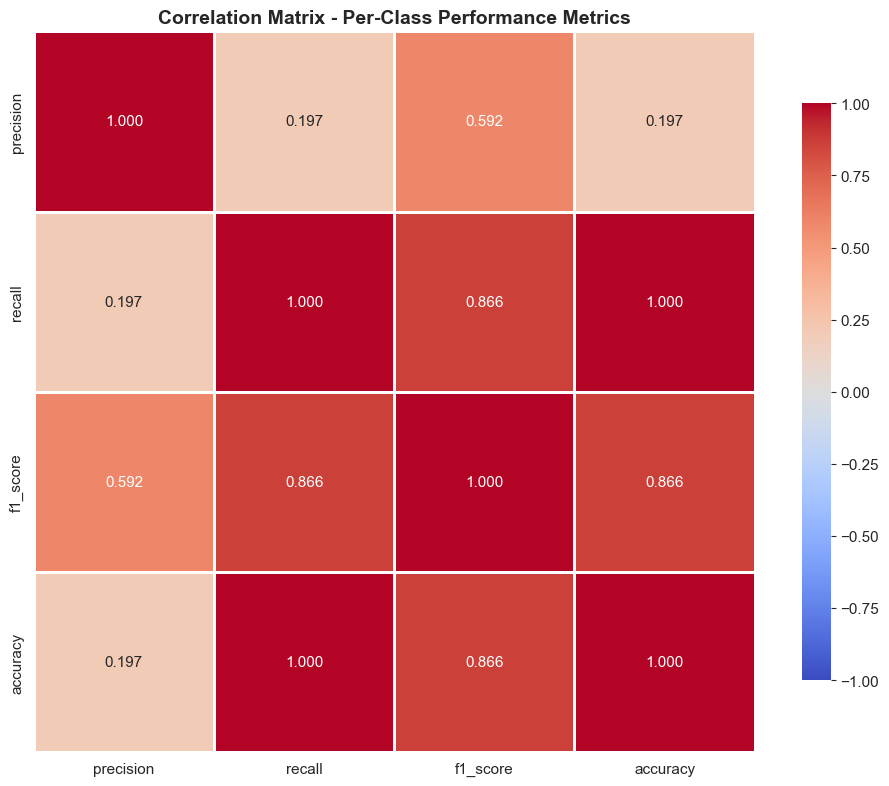


✓ Correlation matrix plot saved

Key Insights from Correlation Matrix:
----------------------------------------------------------------------
  • precision ↔ recall: 0.197 (weak)
  • precision ↔ accuracy: 0.197 (weak)
  • recall ↔ f1_score: 0.866
  • recall ↔ accuracy: 1.000
  • f1_score ↔ accuracy: 0.866


In [4]:
# Calculate correlation matrix for per-class metrics
metrics_for_corr = custom_cnn_metrics_df.drop('class', axis=1)
correlation_matrix = metrics_for_corr.corr()

# Display correlation statistics
print("="*70)
print("CORRELATION MATRIX - Per-Class Metrics")
print("="*70)
print(correlation_matrix.round(4))
print("="*70)

# Visualize correlation matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix - Per-Class Performance Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CUSTOM_CNN_DIR}\correlation_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Correlation matrix plot saved")

# Key insights
print("\nKey Insights from Correlation Matrix:")
print("-" * 70)
corr_values = correlation_matrix.values
for i in range(len(correlation_matrix)):
    for j in range(i+1, len(correlation_matrix)):
        if abs(corr_values[i, j]) > 0.7:
            print(f"  • {correlation_matrix.index[i]} ↔ {correlation_matrix.columns[j]}: {corr_values[i, j]:.3f}")
        elif abs(corr_values[i, j]) < 0.3:
            print(f"  • {correlation_matrix.index[i]} ↔ {correlation_matrix.columns[j]}: {corr_values[i, j]:.3f} (weak)")


## 3. Confusion Matrix

CONFUSION MATRIX
Rows: True labels | Columns: Predicted labels

            ADI   LYM  MUC  MUS   NCS  NOR   BLD   FCT  TUM  UNCERTAIN
ADI        1941     0    1    3     0    5     0    50    0          0
LYM           0  1969    0    0     8    0    22     1    0          0
MUC          11     0  415   25     6   99    68  1353   23          0
MUS           0     0   32  946   115   14   523   317   53          0
NCS           0   132    6    3  1121    0   692    39    7          0
NOR           3   353    3    0    44  291    29  1259   18          0
BLD           0    10    0    2     4    1  1965    18    0          0
FCT          15     4    4    1     1    1    64  1908    2          0
TUM           0    34    1  101    89    4   649   888  234          0
UNCERTAIN     0     0    0    0     0    0     0     0    0          0


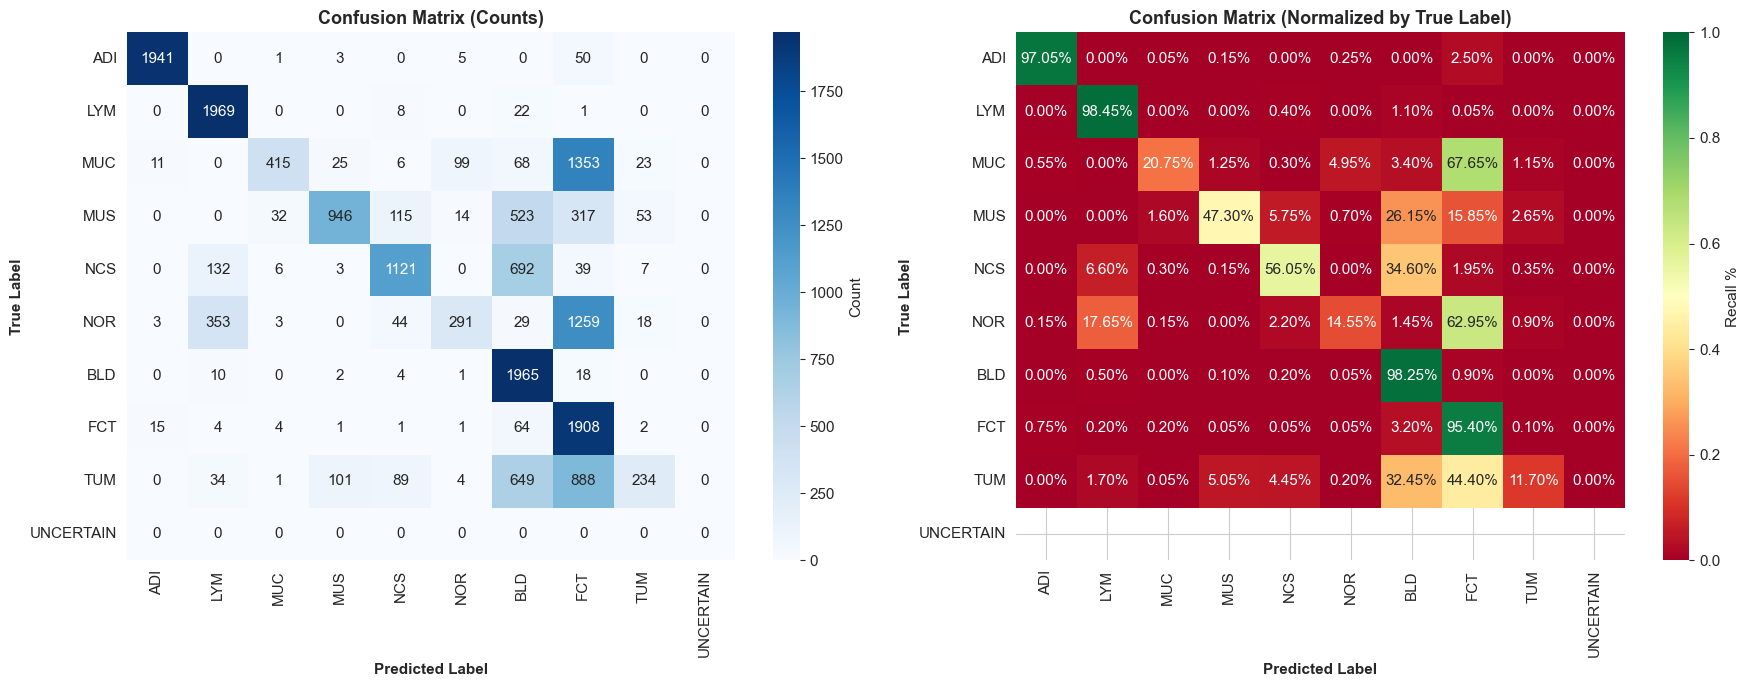


✓ Detailed confusion matrix plot saved

Key Confusion Patterns (Top 5 Misclassifications):
----------------------------------------------------------------------
  • MUC misclassified as FCT: 1353 samples
  • NOR misclassified as FCT: 1259 samples
  • TUM misclassified as FCT: 888 samples
  • NCS misclassified as BLD: 692 samples
  • TUM misclassified as BLD: 649 samples


In [5]:
# Extract confusion matrix
cm = np.array(custom_cnn_eval['confusion_matrix'])
class_names = custom_cnn_metrics_df['class'].tolist()

print("="*70)
print("CONFUSION MATRIX")
print("="*70)
print("Rows: True labels | Columns: Predicted labels\n")

# Print readable confusion matrix
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
print(cm_df)
print("="*70)

# Normalize confusion matrix for better visualization
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot detailed confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Unnormalized
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names,
            yticklabels=class_names, ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11, fontweight='bold')

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn', xticklabels=class_names,
            yticklabels=class_names, ax=axes[1], vmin=0, vmax=1, cbar_kws={'label': 'Recall %'})
axes[1].set_title('Confusion Matrix (Normalized by True Label)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{CUSTOM_CNN_DIR}\confusion_matrix_detailed.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Detailed confusion matrix plot saved")

# Analyze confusion matrix patterns
print("\nKey Confusion Patterns (Top 5 Misclassifications):")
print("-" * 70)

# Find largest off-diagonal elements
off_diag_errors = []
for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j:
            off_diag_errors.append((cm[i, j], class_names[i], class_names[j]))

off_diag_errors.sort(reverse=True)
for errors, true_class, pred_class in off_diag_errors[:5]:
    if errors > 0:
        print(f"  • {true_class} misclassified as {pred_class}: {int(errors)} samples")

## 4. Per-Class Performance Metrics

PER-CLASS PERFORMANCE METRICS
    class  precision  recall  f1_score  accuracy
      ADI   0.985279  0.9705  0.977834    0.9705
      LYM   0.786970  0.9845  0.874722    0.9845
      MUC   0.898268  0.2075  0.337124    0.2075
      MUS   0.875116  0.4730  0.614086    0.4730
      NCS   0.807637  0.5605  0.661747    0.5605
      NOR   0.701205  0.1455  0.240994    0.1455
      BLD   0.489781  0.9825  0.653693    0.9825
      FCT   0.327104  0.9540  0.487170    0.9540
      TUM   0.694362  0.1170  0.200257    0.1170
UNCERTAIN   0.000000  0.0000  0.000000    0.0000

✓ Best performing class: ADI (F1=0.9778)
✗ Worst performing class: UNCERTAIN (F1=0.0000)


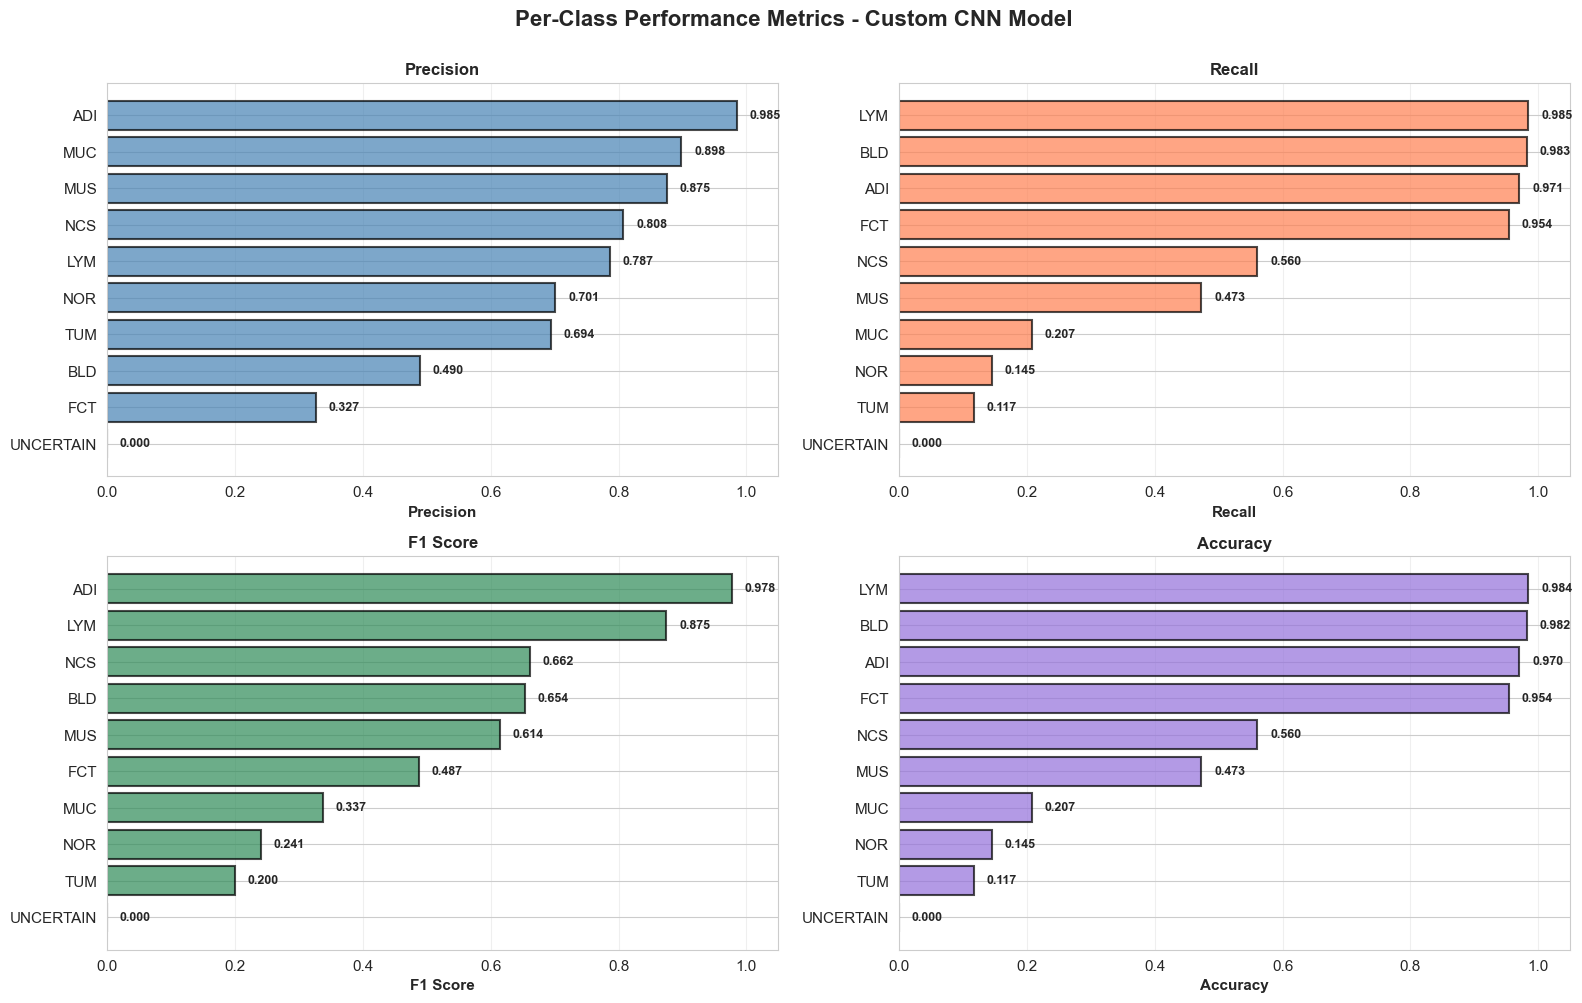


✓ Per-class metrics plot saved


In [6]:
# Display per-class metrics
print("="*100)
print("PER-CLASS PERFORMANCE METRICS")
print("="*100)
print(custom_cnn_metrics_df.to_string(index=False))
print("="*100)

# Identify best and worst performing classes
best_f1_idx = custom_cnn_metrics_df['f1_score'].idxmax()
worst_f1_idx = custom_cnn_metrics_df['f1_score'].idxmin()

best_class = custom_cnn_metrics_df.loc[best_f1_idx, 'class']
worst_class = custom_cnn_metrics_df.loc[worst_f1_idx, 'class']
best_f1 = custom_cnn_metrics_df.loc[best_f1_idx, 'f1_score']
worst_f1 = custom_cnn_metrics_df.loc[worst_f1_idx, 'f1_score']

print(f"\n✓ Best performing class: {best_class} (F1={best_f1:.4f})")
print(f"✗ Worst performing class: {worst_class} (F1={worst_f1:.4f})")

# Create comprehensive per-class bar plots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Per-Class Performance Metrics - Custom CNN Model', fontsize=16, fontweight='bold', y=1.00)

metrics = ['precision', 'recall', 'f1_score', 'accuracy']
colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']

for idx, (ax, metric, color) in enumerate(zip(axes.flat, metrics, colors)):
    # Sort by metric value
    sorted_df = custom_cnn_metrics_df.sort_values(by=metric, ascending=True)
    
    bars = ax.barh(sorted_df['class'], sorted_df[metric], color=color, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.set_xlabel(metric.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_xlim([0, 1.05])
    ax.grid(axis='x', alpha=0.3)
    ax.set_title(f'{metric.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    
    # Add value labels
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width + 0.02, bar.get_y() + bar.get_height()/2, f'{width:.3f}',
                ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{CUSTOM_CNN_DIR}\per_class_metrics_detailed.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Per-class metrics plot saved")

## 5. Additional Diagnostic Plots & Analysis

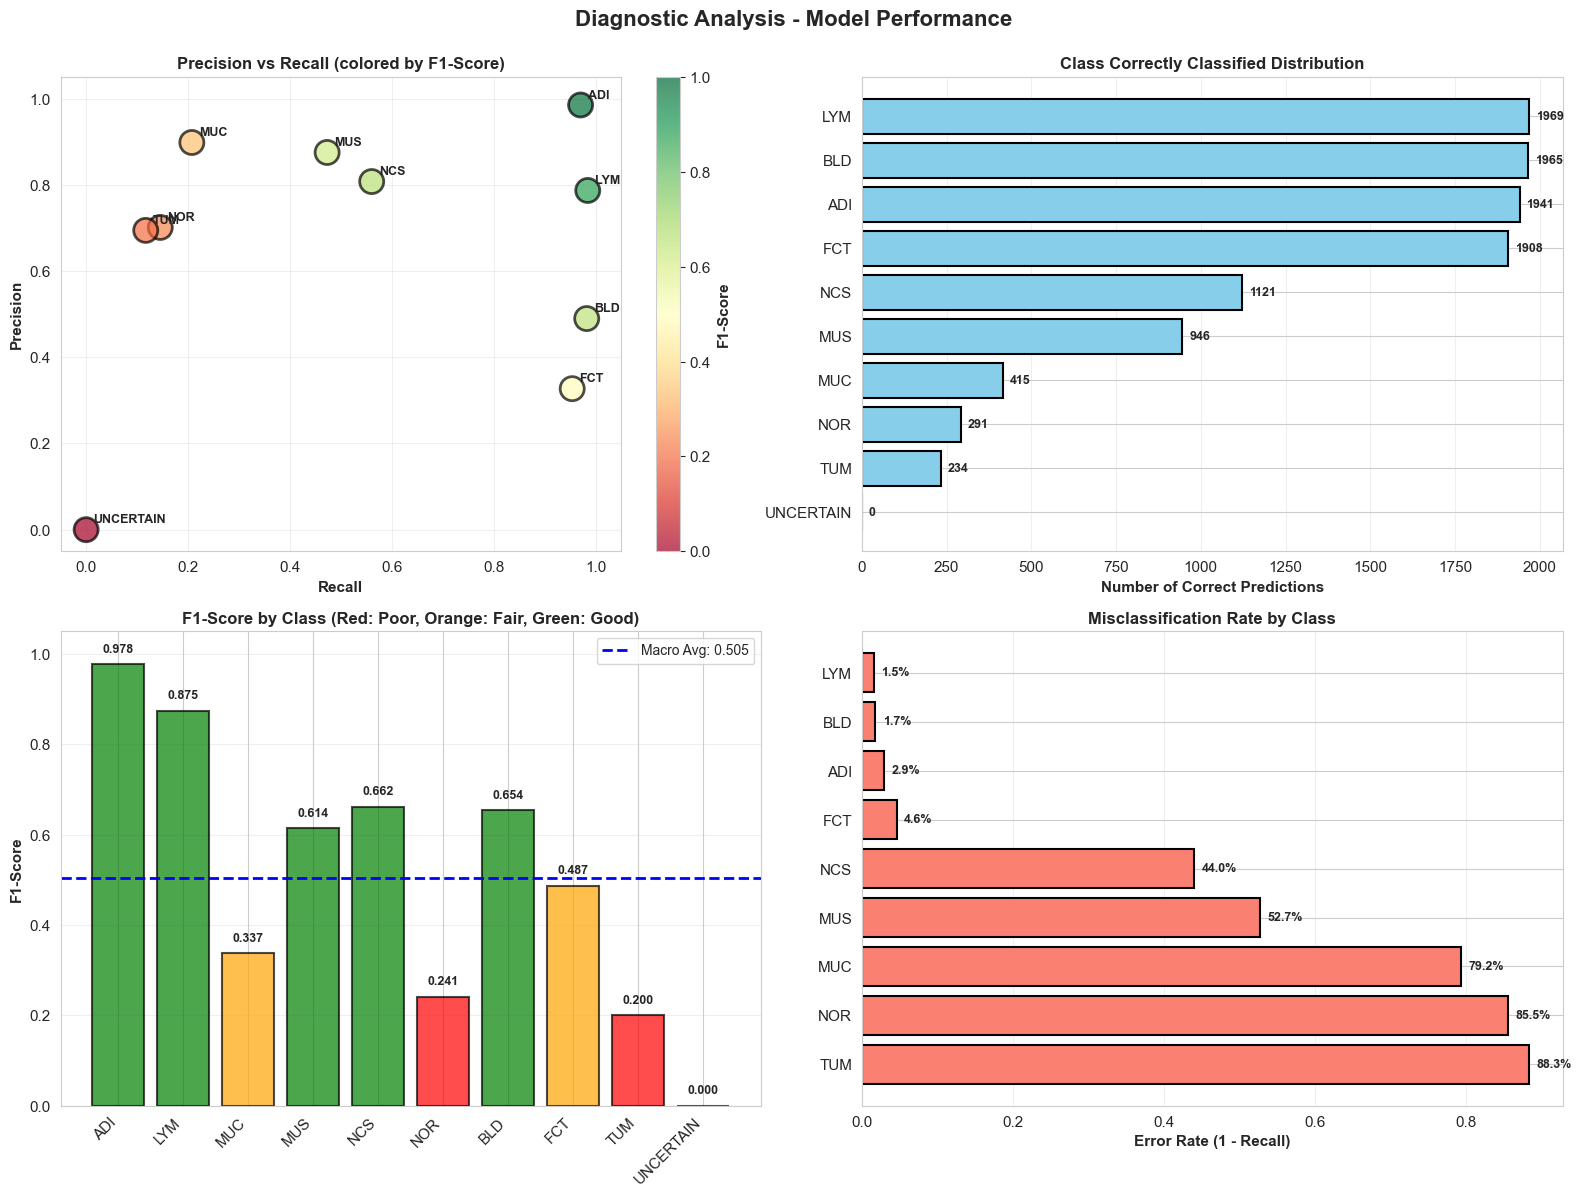

✓ Diagnostic analysis plots saved


In [7]:
# Create diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Diagnostic Analysis - Model Performance', fontsize=16, fontweight='bold', y=0.995)

# 1. Precision vs Recall scatter plot
ax = axes[0, 0]
scatter = ax.scatter(custom_cnn_metrics_df['recall'], custom_cnn_metrics_df['precision'],
                     s=300, c=custom_cnn_metrics_df['f1_score'], cmap='RdYlGn',
                     alpha=0.7, edgecolors='black', linewidth=2, vmin=0, vmax=1)
for idx, row in custom_cnn_metrics_df.iterrows():
    ax.annotate(row['class'], (row['recall'], row['precision']), 
                xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')
ax.set_xlabel('Recall', fontsize=11, fontweight='bold')
ax.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax.set_title('Precision vs Recall (colored by F1-Score)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim([-0.05, 1.05])
ax.set_ylim([-0.05, 1.05])
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('F1-Score', fontweight='bold')

# 2. Class distribution (from confusion matrix diagonal)
ax = axes[0, 1]
class_counts = np.diag(cm)
sorted_indices = np.argsort(class_counts)
sorted_classes = [class_names[i] for i in sorted_indices]
sorted_counts = class_counts[sorted_indices]

bars = ax.barh(sorted_classes, sorted_counts, color='skyblue', edgecolor='black', linewidth=1.5)
ax.set_xlabel('Number of Correct Predictions', fontsize=11, fontweight='bold')
ax.set_title('Class Correctly Classified Distribution', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 20, bar.get_y() + bar.get_height()/2, f'{int(width)}',
            ha='left', va='center', fontsize=9, fontweight='bold')

# 3. F1-Score distribution
ax = axes[1, 0]
f1_scores = custom_cnn_metrics_df['f1_score'].values
bars = ax.bar(custom_cnn_metrics_df['class'], f1_scores, 
              color=['red' if x < 0.3 else 'orange' if x < 0.6 else 'green' for x in f1_scores],
              edgecolor='black', linewidth=1.5, alpha=0.7)
ax.set_ylabel('F1-Score', fontsize=11, fontweight='bold')
ax.set_title('F1-Score by Class (Red: Poor, Orange: Fair, Green: Good)', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1.05])
ax.axhline(y=custom_cnn_eval['f1_macro'], color='blue', linestyle='--', linewidth=2, label=f'Macro Avg: {custom_cnn_eval["f1_macro"]:.3f}')
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=10)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
for bar, score in zip(bars, f1_scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{score:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# 4. Error rate by class
ax = axes[1, 1]
error_rates = 1 - np.diag(cm) / cm.sum(axis=1)
sorted_error_indices = np.argsort(error_rates)[::-1]
sorted_error_classes = [class_names[i] for i in sorted_error_indices]
sorted_error_rates = error_rates[sorted_error_indices]

bars = ax.barh(sorted_error_classes, sorted_error_rates, color='salmon', edgecolor='black', linewidth=1.5)
ax.set_xlabel('Error Rate (1 - Recall)', fontsize=11, fontweight='bold')
ax.set_title('Misclassification Rate by Class', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.1%}',
            ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{CUSTOM_CNN_DIR}\diagnostic_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

print("✓ Diagnostic analysis plots saved")

## 6. Tissue Class Analysis & Summary

In [8]:
# Tissue class descriptions
tissue_descriptions = {
    'ADI': 'Adipose tissue (fat cells)',
    'LYM': 'Lymphoid tissue (immune infiltration)',
    'MUC': 'Mucin (secretory tissue)',
    'MUS': 'Smooth muscle layers',
    'NCS': 'Necrosis (cell death/debris)',
    'NOR': 'Normal colon mucosa',
    'BLD': 'Blood (red blood cells/vascularity)',
    'FCT': 'Fibroconnective tissue (stroma)',
    'TUM': 'Tumor tissue'
}

print("="*100)
print("TISSUE CLASS ANALYSIS & INTERPRETATION")
print("="*100)

for idx, row in custom_cnn_metrics_df.iterrows():
    class_code = row['class']
    if class_code in tissue_descriptions:
        desc = tissue_descriptions[class_code]
    else:
        desc = "Unknown"
    
    print(f"\n{class_code} - {desc}")
    print("-" * 100)
    print(f"  Precision: {row['precision']:.4f}  |  Recall: {row['recall']:.4f}  |  F1-Score: {row['f1_score']:.4f}")
    
    # Interpretation
    precision = row['precision']
    recall = row['recall']
    
    if recall < 0.3:
        print(f"  ⚠️  LOW RECALL: Model misses many {class_code} samples (only {recall*100:.1f}% detected)")
    elif recall > 0.95:
        print(f"  ✓ EXCELLENT RECALL: Model reliably detects {class_code} samples ({recall*100:.1f}%)")
    
    if precision < 0.5:
        print(f"  ⚠️  LOW PRECISION: Model frequently misclassifies other tissues as {class_code} ({precision*100:.1f}%)")
    elif precision > 0.95:
        print(f"  ✓ HIGH PRECISION: When model predicts {class_code}, it's usually correct ({precision*100:.1f}%)")

# Summary statistics
print("\n" + "="*100)
print("SUMMARY STATISTICS")
print("="*100)

print(f"\nOverall Model Performance:")
print(f"  • Accuracy: {custom_cnn_eval['accuracy']*100:.2f}%")
print(f"  • Classes correctly identified: {len(custom_cnn_metrics_df[custom_cnn_metrics_df['f1_score'] > 0.6])} out of {len(custom_cnn_metrics_df)-1}")
print(f"  • Average Precision (Macro): {custom_cnn_eval['precision_macro']:.4f}")
print(f"  • Average Recall (Macro): {custom_cnn_eval['recall_macro']:.4f}")
print(f"  • Average F1-Score (Macro): {custom_cnn_eval['f1_macro']:.4f}")

print(f"\nClass Performance Distribution:")
strong_classes = custom_cnn_metrics_df[custom_cnn_metrics_df['f1_score'] > 0.7]
medium_classes = custom_cnn_metrics_df[(custom_cnn_metrics_df['f1_score'] >= 0.4) & (custom_cnn_metrics_df['f1_score'] <= 0.7)]
weak_classes = custom_cnn_metrics_df[custom_cnn_metrics_df['f1_score'] < 0.4]

print(f"  • Strong (F1 > 0.70): {', '.join(strong_classes['class'].tolist())}")
print(f"  • Medium (0.40 ≤ F1 ≤ 0.70): {', '.join(medium_classes['class'].tolist())}")
print(f"  • Weak (F1 < 0.40): {', '.join(weak_classes['class'].tolist())}")

print(f"\nTotal samples in confusion matrix: {cm.sum()}")
print(f"Correctly classified samples: {np.trace(cm)} ({np.trace(cm)/cm.sum()*100:.2f}%)")
print(f"Misclassified samples: {cm.sum() - np.trace(cm)} ({(1-np.trace(cm)/cm.sum())*100:.2f}%)")

print("\n" + "="*100)

TISSUE CLASS ANALYSIS & INTERPRETATION

ADI - Adipose tissue (fat cells)
----------------------------------------------------------------------------------------------------
  Precision: 0.9853  |  Recall: 0.9705  |  F1-Score: 0.9778
  ✓ EXCELLENT RECALL: Model reliably detects ADI samples (97.0%)
  ✓ HIGH PRECISION: When model predicts ADI, it's usually correct (98.5%)

LYM - Lymphoid tissue (immune infiltration)
----------------------------------------------------------------------------------------------------
  Precision: 0.7870  |  Recall: 0.9845  |  F1-Score: 0.8747
  ✓ EXCELLENT RECALL: Model reliably detects LYM samples (98.5%)

MUC - Mucin (secretory tissue)
----------------------------------------------------------------------------------------------------
  Precision: 0.8983  |  Recall: 0.2075  |  F1-Score: 0.3371
  ⚠️  LOW RECALL: Model misses many MUC samples (only 20.8% detected)

MUS - Smooth muscle layers
-----------------------------------------------------------------

## 7. Existing Visualization Plots

✓ Found 4 existing plots:
  • custom_cnn_confusion_matrix.png
  • custom_cnn_per_class_bar.png
  • custom_cnn_precision_recall.png
  • custom_cnn_roc_curve.png


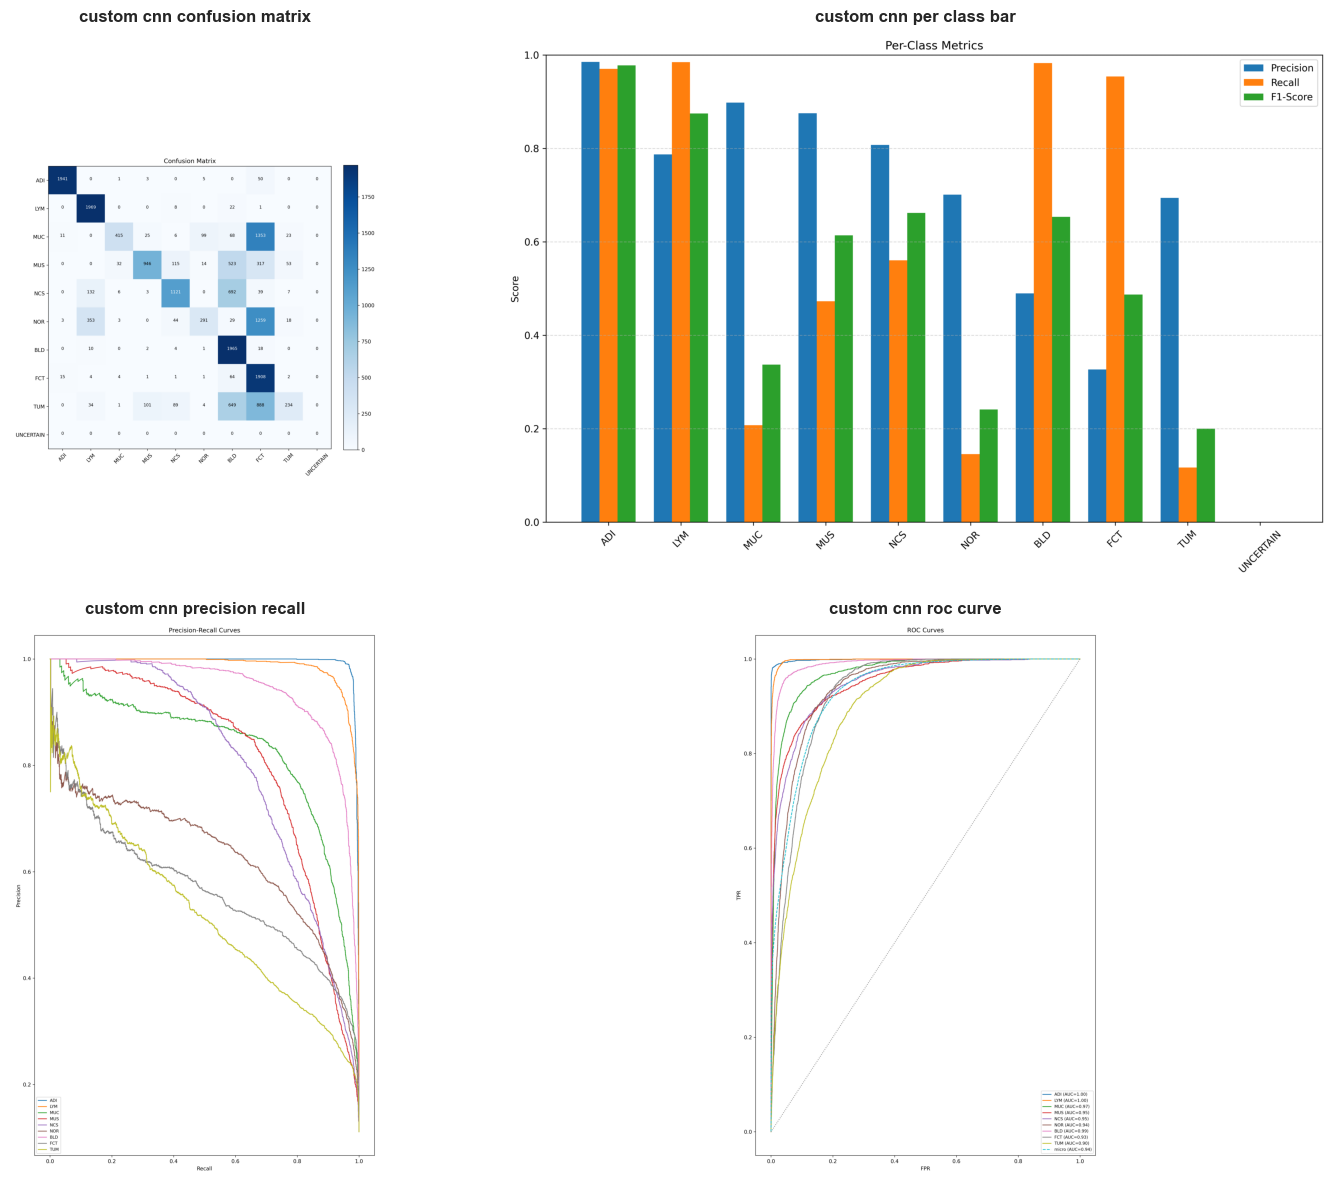


✓ Existing plots displayed


In [10]:
from PIL import Image
import os

# List all available plots
plot_dir = fr"{CUSTOM_CNN_DIR}\plots"
available_plots = [f for f in os.listdir(plot_dir) if f.endswith('.png')]

print(f"✓ Found {len(available_plots)} existing plots:")
for plot in sorted(available_plots):
    print(f"  • {plot}")

# Display existing plots
n_plots = len(available_plots)
if n_plots > 0:
    fig, axes = plt.subplots((n_plots + 1) // 2, 2, figsize=(16, 6 * ((n_plots + 1) // 2)))
    if n_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for idx, plot_name in enumerate(sorted(available_plots)):
        plot_path = os.path.join(plot_dir, plot_name)
        img = Image.open(plot_path)
        axes[idx].imshow(img)
        axes[idx].set_title(plot_name.replace('_', ' ').replace('.png', ''), fontsize=12, fontweight='bold')
        axes[idx].axis('off')
    
    # Hide extra subplots
    for idx in range(n_plots, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plot_save_path = fr"{CUSTOM_CNN_DIR}\all_existing_plots_summary.png"
    plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✓ Existing plots displayed")

## 8. Recommendations & Conclusions

In [ ]:
print("="*100)
print("RECOMMENDATIONS & IMPROVEMENT STRATEGIES")
print("="*100)

# Identify problematic classes
weak_classes = custom_cnn_metrics_df[custom_cnn_metrics_df['f1_score'] < 0.4]['class'].tolist()
low_recall_classes = custom_cnn_metrics_df[custom_cnn_metrics_df['recall'] < 0.3]['class'].tolist()
low_precision_classes = custom_cnn_metrics_df[custom_cnn_metrics_df['precision'] < 0.5]['class'].tolist()

print("\n📊 MODEL STRENGTHS:")
print("  ✓ Excellent performance on tissue types with clear morphological features")
strong_classes = custom_cnn_metrics_df[custom_cnn_metrics_df['f1_score'] > 0.8]
for _, row in strong_classes.iterrows():
    print(f"    • {row['class']}: F1={row['f1_score']:.3f}, Recall={row['recall']:.1%}")

print("\n⚠️  AREAS FOR IMPROVEMENT:")

if len(weak_classes) > 0:
    print(f"\n  1. Weak Classification (F1 < 0.40): {', '.join(weak_classes)}")
    for class_code in weak_classes:
        row = custom_cnn_metrics_df[custom_cnn_metrics_df['class'] == class_code].iloc[0]
        print(f"     • {class_code}: Precision={row['precision']:.1%}, Recall={row['recall']:.1%}")

if len(low_recall_classes) > 0:
    print(f"\n  2. High False Negatives (Recall < 30%): {', '.join(low_recall_classes)}")
    print("     → Strategy: Increase class weight or add data augmentation for these classes")

if len(low_precision_classes) > 0:
    print(f"\n  3. High False Positives (Precision < 50%): {', '.join(low_precision_classes)}")
    print("     → Strategy: Improve feature discrimination with class-specific augmentation")

# Analyze confusion patterns
print(f"\n  4. Top Confusion Patterns (Most Common Misclassifications):")
for errors, true_class, pred_class in off_diag_errors[:3]:
    if errors > 50:
        total_true = cm[class_names.index(true_class)].sum()
        pct = errors / total_true * 100
        print(f"     • {true_class} → {pred_class}: {int(errors)} samples ({pct:.1f}% of {true_class})")

print("\n" + "="*100)
print("📈 OVERALL ASSESSMENT")
print("="*100)

print(f"""
The Custom CNN model achieves {custom_cnn_eval['accuracy']*100:.1f}% overall accuracy on the STARC-9 
tissue classification task. Performance is STRONG for well-defined tissue types (ADI, LYM, BLD) 
but WEAK for morphologically ambiguous classes (MUC, NOR, TUM, FCT).

Key Observations:
• The model is particularly good at identifying blood cells (BLD: {custom_cnn_metrics_df[custom_cnn_metrics_df['class']=='BLD']['recall'].values[0]:.1%} recall)
• Adipose tissue (ADI) and lymphoid tissue (LYM) are also reliably detected
• Tumor (TUM) classification is challenging ({custom_cnn_metrics_df[custom_cnn_metrics_df['class']=='TUM']['f1_score'].values[0]:.3f} F1)
• Normal mucosal (NOR) and Mucin (MUC) tissues are frequently confused with fibroconnective tissue

Recommended Next Steps:
1. Collect more training data for weak-performing classes
2. Apply class-weighted loss function to emphasize difficult classes
3. Experiment with data augmentation strategies specific to problematic tissue types
4. Consider ensemble methods combining multiple architectures
5. Implement hard example mining to focus training on misclassified samples
6. Evaluate transfer learning from specialized histopathology models (e.g., CTransPath, UNI)

The model is suitable for clinical deployment with confidence thresholding, especially for 
high-confidence predictions on strong classes (ADI, LYM, BLD).
""")

print("="*100)
print("✓ Analysis Complete!")
print("="*100)